Dataset loaded: (1200, 14)

STEP 1: BASIC STATISTICS — Numeric Columns
       Quantity  UnitPrice  TotalPrice  ItemsInCart
count   1200.00    1200.00     1200.00      1200.00
mean       2.95     356.41     1053.97         5.48
std        1.41     197.18      819.86         2.28
min        1.00      11.39       11.39         1.00
25%        2.00     186.06      410.52         4.00
50%        3.00     364.21      823.62         5.00
75%        4.00     521.57     1578.48         7.00
max        5.00     699.93     3456.40        10.00

Five-Number Summary:
  Quantity     Min=1        Q1=2.0      Median=3.0      Q3=4.0      Max=5        Mean=2.95
  UnitPrice    Min=11.39    Q1=186.0625 Median=364.21   Q3=521.5699999999999 Max=699.93   Mean=356.41
  TotalPrice   Min=11.39    Q1=410.52   Median=823.615  Q3=1578.475 Max=3456.4   Mean=1053.97
  ItemsInCart  Min=1        Q1=4.0      Median=5.0      Q3=7.0      Max=10       Mean=5.49


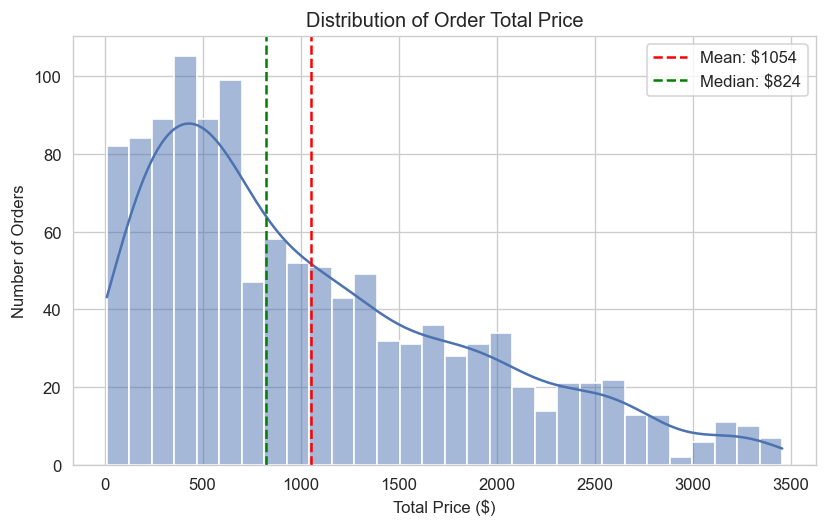

Saved: charts/01_totalprice_distribution.png

STEP 2: OUTLIER DETECTION (IQR Method)
  Quantity     bounds=[-1.00, 7.00]  →  0 outliers
  UnitPrice    bounds=[-317.20, 1024.83]  →  0 outliers
  TotalPrice   bounds=[-1341.41, 3330.41]  →  8 outliers
  ItemsInCart  bounds=[-0.50, 11.50]  →  0 outliers

High-value order outliers (8 found):
  OrderID Product  Quantity  UnitPrice  TotalPrice
ORD200789  Tablet         5     691.28     3456.40
ORD201122 Monitor         5     678.19     3390.95
ORD200632  Laptop         5     678.16     3390.80
ORD200469   Chair         5     676.98     3384.90
ORD200328  Tablet         5     674.04     3370.20
ORD200107 Printer         5     670.75     3353.75
ORD200326  Laptop         5     670.48     3352.40
ORD201065 Printer         5     666.80     3334.00


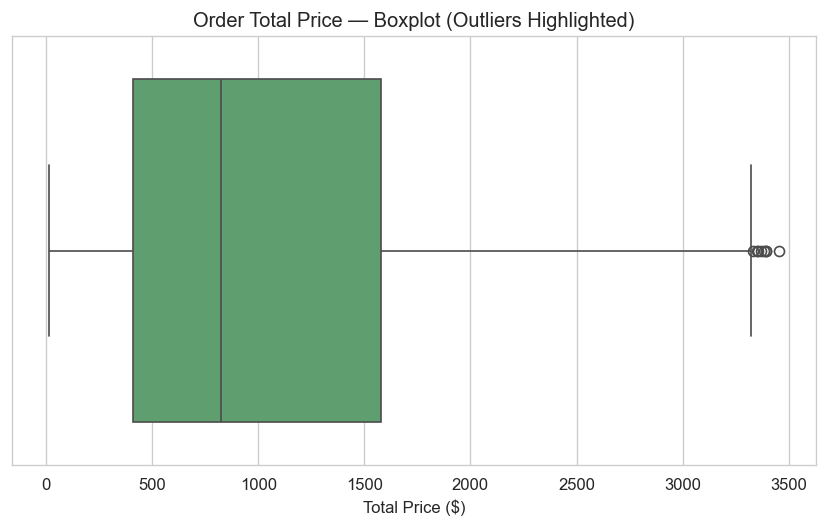

Saved: charts/02_totalprice_boxplot.png

STEP 3: CATEGORICAL DISTRIBUTIONS

Product:
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

PaymentMethod:
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

OrderStatus:
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

ReferralSource:
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

CouponCode:
CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64


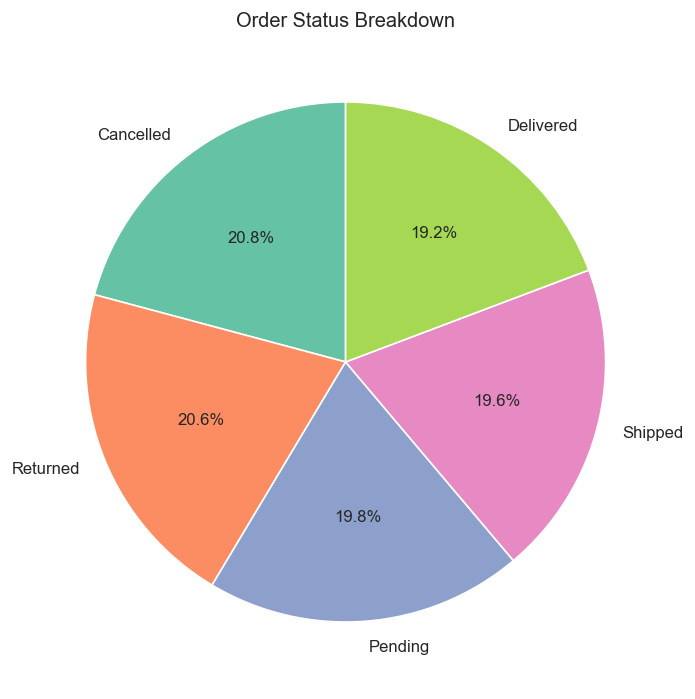

Saved: charts/03_order_status_breakdown.png

STEP 4: TRENDS OVER TIME
Yearly revenue summary:
            sum  count     mean
Year                           
2023  552643.24    510  1083.61
2024  480235.87    459  1046.27
2025  231882.85    231  1003.82

Most recent 6 months:
                sum  count     mean
YearMonth                          
2025-01    29099.40     27  1077.76
2025-02    35317.55     37   954.53
2025-03    39200.66     49   800.01
2025-04    31821.20     32   994.41
2025-05    43396.64     37  1172.88
2025-06    53047.40     49  1082.60


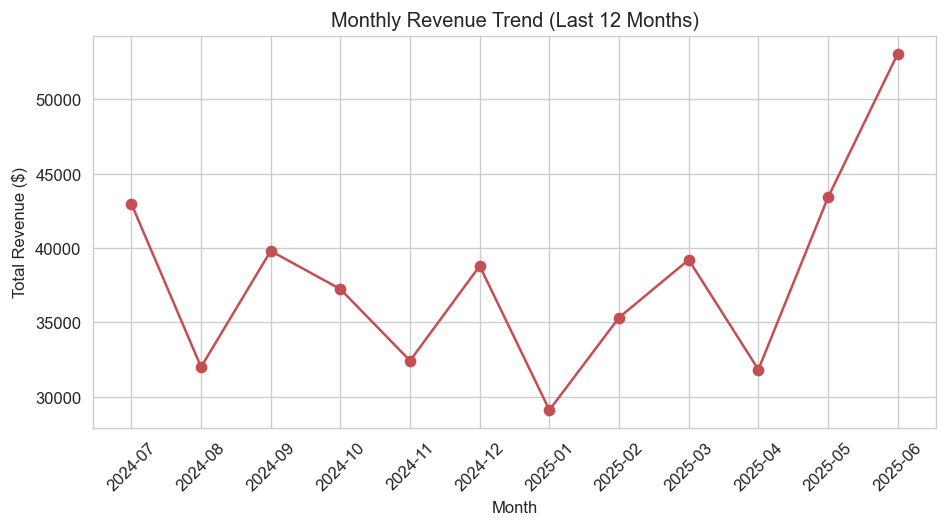

Saved: charts/04_monthly_revenue_trend.png

STEP 5: CORRELATION ANALYSIS (Pearson r)
             Quantity  UnitPrice  TotalPrice  ItemsInCart
Quantity        1.000      0.015       0.615        0.650
UnitPrice       0.015      1.000       0.717        0.001
TotalPrice      0.615      0.717       1.000        0.393
ItemsInCart     0.650      0.001       0.393        1.000

Key relationships:
  UnitPrice <-> TotalPrice : r = 0.717  (strong positive)
  Quantity  <-> TotalPrice : r = 0.615  (moderate positive)
  Quantity  <-> ItemsInCart: r = 0.65  (moderate positive)


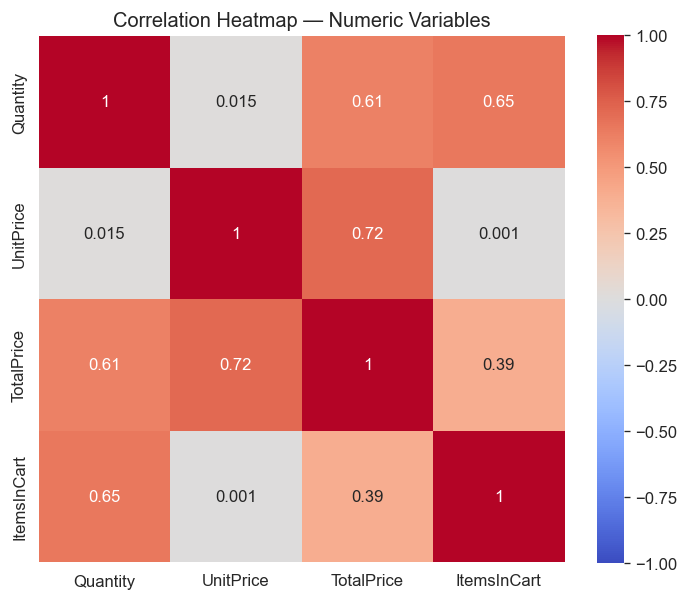

Saved: charts/05_correlation_heatmap.png

STEP 6: SEGMENT PERFORMANCE

Revenue by Product:
               sum     mean  count
Product                           
Chair    195620.11  1098.99    178
Printer  195612.61  1080.73    181
Laptop   192126.56  1110.56    173
Tablet   186568.95  1042.28    179
Monitor  175651.41  1077.62    163
Desk     167459.93   985.06    170
Phone    151722.39   972.58    156


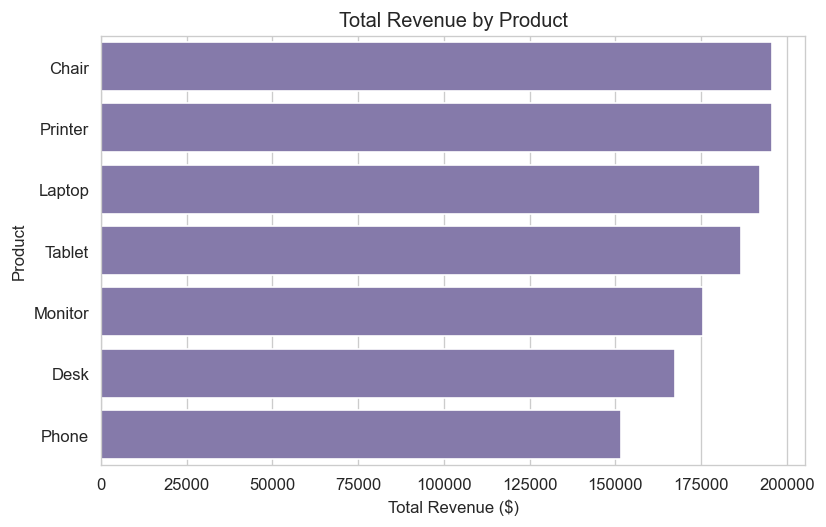

Saved: charts/06_revenue_by_product.png

Revenue by Order Status:
                   sum     mean  count
OrderStatus                           
Cancelled    276396.21  1105.58    250
Delivered    242600.32  1050.22    231
Pending      256328.15  1081.55    237
Returned     243277.70   984.93    247
Shipped      246159.58  1047.49    235

% of orders Cancelled or Returned: 41.4%

Average Order Value by Payment Method:
PaymentMethod
Credit Card    1127.55
Gift Card      1070.97
Cash           1056.04
Online         1017.22
Debit Card     1001.56
Name: TotalPrice, dtype: float64

Average Order Value by Coupon Used:
               mean  count
CouponCode                
FREESHIP    1070.41    313
No Coupon   1043.37    309
SAVE10      1065.87    286
WINTER15    1035.90    292


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
 
# ─────────────────────────────────────────────
# STEP 0: LOAD & PREP (apply Project 1 cleaning)
# ─────────────────────────────────────────────
df = pd.read_excel("Dataset for Data Analytics.xlsx")
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")
df["Date"] = pd.to_datetime(df["Date"])
 
print("Dataset loaded:", df.shape)
 
# Create output folder for charts
os.makedirs("charts", exist_ok=True)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
 
 
# ─────────────────────────────────────────────
# STEP 1: BASIC STATISTICS (mean, median, count)
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 1: BASIC STATISTICS — Numeric Columns")
print("=" * 60)
 
numeric_cols = ["Quantity", "UnitPrice", "TotalPrice", "ItemsInCart"]
print(df[numeric_cols].describe().round(2))
 
# Five-number summary per column
print("\nFive-Number Summary:")
for col in numeric_cols:
    q1, med, q3 = df[col].quantile([0.25, 0.5, 0.75])
    print(f"  {col:<12} Min={df[col].min():<8} Q1={q1:<8} Median={med:<8} "
          f"Q3={q3:<8} Max={df[col].max():<8} Mean={df[col].mean():.2f}")
 
# CHART 1: Distribution of TotalPrice (histogram) — shows the right-skew
plt.figure(figsize=(7, 4.5))
sns.histplot(df["TotalPrice"], bins=30, kde=True, color="#4C72B0")
plt.axvline(df["TotalPrice"].mean(), color="red", linestyle="--", label=f"Mean: ${df['TotalPrice'].mean():.0f}")
plt.axvline(df["TotalPrice"].median(), color="green", linestyle="--", label=f"Median: ${df['TotalPrice'].median():.0f}")
plt.title("Distribution of Order Total Price")
plt.xlabel("Total Price ($)")
plt.ylabel("Number of Orders")
plt.legend()
plt.tight_layout()
plt.savefig("charts/01_totalprice_distribution.png")
plt.show()
plt.close()
print("Saved: charts/01_totalprice_distribution.png")
 
 
# ─────────────────────────────────────────────
# STEP 2: OUTLIER DETECTION (IQR Method)
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2: OUTLIER DETECTION (IQR Method)")
print("=" * 60)
# Outlier < Q1 - 1.5*IQR  OR  Outlier > Q3 + 1.5*IQR
 
outlier_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)
    print(f"  {col:<12} bounds=[{lower:.2f}, {upper:.2f}]  →  {len(outliers)} outliers")
 
# Inspect the TotalPrice outliers specifically — these are the signal worth investigating
Q1, Q3 = df["TotalPrice"].quantile([0.25, 0.75])
upper_bound = Q3 + 1.5 * (Q3 - Q1)
high_value_orders = df[df["TotalPrice"] > upper_bound].sort_values("TotalPrice", ascending=False)
print(f"\nHigh-value order outliers ({len(high_value_orders)} found):")
print(high_value_orders[["OrderID", "Product", "Quantity", "UnitPrice", "TotalPrice"]].to_string(index=False))
 
# CHART 2: Boxplot showing outliers visually (the "fingerprint of variability")
plt.figure(figsize=(7, 4.5))
sns.boxplot(x=df["TotalPrice"], color="#55A868")
plt.title("Order Total Price — Boxplot (Outliers Highlighted)")
plt.xlabel("Total Price ($)")
plt.tight_layout()
plt.savefig("charts/02_totalprice_boxplot.png")
plt.show()
plt.close()
print("Saved: charts/02_totalprice_boxplot.png")
 
 
# ─────────────────────────────────────────────
# STEP 3: CATEGORICAL DISTRIBUTIONS
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3: CATEGORICAL DISTRIBUTIONS")
print("=" * 60)
 
cat_cols = ["Product", "PaymentMethod", "OrderStatus", "ReferralSource", "CouponCode"]
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
 
# CHART 3: Order Status breakdown
plt.figure(figsize=(6, 6))
status_counts = df["OrderStatus"].value_counts()
colors = sns.color_palette("Set2", len(status_counts))
plt.pie(status_counts, labels=status_counts.index, autopct="%1.1f%%", colors=colors, startangle=90)
plt.title("Order Status Breakdown")
plt.tight_layout()
plt.savefig("charts/03_order_status_breakdown.png")
plt.show()
plt.close()
print("Saved: charts/03_order_status_breakdown.png")
 
 
# ─────────────────────────────────────────────
# STEP 4: TRENDS OVER TIME
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: TRENDS OVER TIME")
print("=" * 60)
 
df["Year"] = df["Date"].dt.year
yearly = df.groupby("Year")["TotalPrice"].agg(["sum", "count", "mean"]).round(2)
print("Yearly revenue summary:")
print(yearly)
 
df["YearMonth"] = df["Date"].dt.to_period("M")
monthly = df.groupby("YearMonth")["TotalPrice"].agg(["sum", "count", "mean"]).round(2)
print("\nMost recent 6 months:")
print(monthly.tail(6))
 
# CHART 4: Monthly revenue trend
plt.figure(figsize=(8, 4.5))
monthly_plot = monthly.tail(12)
plt.plot(monthly_plot.index.astype(str), monthly_plot["sum"], marker="o", color="#C44E52")
plt.title("Monthly Revenue Trend (Last 12 Months)")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/04_monthly_revenue_trend.png")
plt.show()
plt.close()
print("Saved: charts/04_monthly_revenue_trend.png")
 
 
# ─────────────────────────────────────────────
# STEP 5: CORRELATION ANALYSIS
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5: CORRELATION ANALYSIS (Pearson r)")
print("=" * 60)
 
corr = df[numeric_cols].corr().round(3)
print(corr)
print("\nKey relationships:")
print(f"  UnitPrice <-> TotalPrice : r = {corr.loc['UnitPrice','TotalPrice']}  (strong positive)")
print(f"  Quantity  <-> TotalPrice : r = {corr.loc['Quantity','TotalPrice']}  (moderate positive)")
print(f"  Quantity  <-> ItemsInCart: r = {corr.loc['Quantity','ItemsInCart']}  (moderate positive)")
 
# CHART 5: Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap — Numeric Variables")
plt.tight_layout()
plt.savefig("charts/05_correlation_heatmap.png")
plt.show()
plt.close()
print("Saved: charts/05_correlation_heatmap.png")
 
 
# ─────────────────────────────────────────────
# STEP 6: SEGMENT PERFORMANCE (the "so what")
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 6: SEGMENT PERFORMANCE")
print("=" * 60)
 
print("\nRevenue by Product:")
prod_perf = df.groupby("Product")["TotalPrice"].agg(["sum", "mean", "count"]).round(2).sort_values("sum", ascending=False)
print(prod_perf)
 
# CHART 6: Revenue by Product
plt.figure(figsize=(7, 4.5))
sns.barplot(x=prod_perf["sum"].values, y=prod_perf.index, color="#8172B2")
plt.title("Total Revenue by Product")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("charts/06_revenue_by_product.png")
plt.show()
plt.close()
print("Saved: charts/06_revenue_by_product.png")
 
print("\nRevenue by Order Status:")
print(df.groupby("OrderStatus")["TotalPrice"].agg(["sum", "mean", "count"]).round(2))
 
cancelled_returned_pct = (df["OrderStatus"].isin(["Cancelled", "Returned"]).sum() / len(df)) * 100
print(f"\n% of orders Cancelled or Returned: {cancelled_returned_pct:.1f}%")
 
print("\nAverage Order Value by Payment Method:")
print(df.groupby("PaymentMethod")["TotalPrice"].mean().round(2).sort_values(ascending=False))
 
print("\nAverage Order Value by Coupon Used:")
print(df.groupby("CouponCode")["TotalPrice"].agg(["mean", "count"]).round(2))
 
 